# Store Data Variability — No Labels Required
## What is computable without income labels?

| Category | Metric | Needs labels? |
|---|---|---|
| Internal spread | Std, IQR, CV per feature | No |
| Internal spread | Total feature variance (trace of cov) | No |
| Internal spread | PCA: effective dimensionality | No |
| Internal spread | Outlier density | No |
| External shift | KS statistic vs reference store | No |
| External shift | Wasserstein distance vs reference | No |
| External shift | PCA centroid distance | No |
| External shift | Classifier discrepancy | No |
| Income-specific | Income CV, IQR, skewness | **Yes** |
| Income-specific | Feature–income Spearman r | **Yes** |

**Key insight:** all geometric/distributional measures of how spread out
customers are in *feature space* need no income labels.
Only the income-specific statistics require the label column.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.stats import ks_2samp, iqr, wasserstein_distance
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.covariance import EllipticEnvelope
import warnings
warnings.filterwarnings("ignore")

STORES = ["whole_foods","kroger","safeway","walmart","thrift_store"]
LABELS = ["Whole Foods","Kroger","Safeway","Walmart","Thrift Store"]
TIERS  = ["High","Median","Median","Median","Low"]
COLORS = ["#185FA5","#1D9E75","#0F6E56","#854F0B","#A32D2D"]

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "font.size": 11,
})
print("Ready")

Ready


## 2. Load data — DROP income labels immediately

In [2]:
df_full = pd.read_csv("grocery_all_stores.csv")

le = LabelEncoder()
le.fit(df_full["segment"])
df_full["segment_enc"] = le.transform(df_full["segment"])

FEAT_COLS = ["age","visits_per_month","avg_basket_usd","monthly_spend_usd",
             "grocery_pct","electronics_pct","apparel_pct","home_pct",
             "private_label_pct","online_orders_pct","coupon_usage_pct",
             "loyalty_score","segment_enc"]

# ── Build label-free dataset ─────────────────────────────────────────────────
# Simulate the real scenario: we have features and store identity,
# but income_usd is NOT available.
df = df_full[["customer_id","store","segment"] + FEAT_COLS].copy()

scaler = StandardScaler()
scaler.fit(df[FEAT_COLS].values.astype(float))

print(f"Dataset: {len(df)} rows, {len(FEAT_COLS)} features, NO income labels")
print(f"Columns: {list(df.columns)}")

Dataset: 1250 rows, 13 features, NO income labels
Columns: ['customer_id', 'store', 'segment', 'age', 'visits_per_month', 'avg_basket_usd', 'monthly_spend_usd', 'grocery_pct', 'electronics_pct', 'apparel_pct', 'home_pct', 'private_label_pct', 'online_orders_pct', 'coupon_usage_pct', 'loyalty_score', 'segment_enc']


## 3. Internal variability — feature-level statistics (no labels)

For each store, compute:
- Mean and std per feature
- **Coefficient of variation (CV = std / mean):** how spread relative to the average
- **IQR:** middle 50% range, robust to outliers
- **Skewness:** whether the distribution leans left or right

In [3]:
SIX = ["avg_basket_usd","coupon_usage_pct","private_label_pct",
       "online_orders_pct","loyalty_score","visits_per_month"]
SIX_LABS = ["Basket $","Coupon %","Priv. label","Online %","Loyalty","Visits/mo"]

feat_stats = {}
for s in STORES:
    sub = df[df["store"]==s]
    feat_stats[s] = {
        f: {"mean": sub[f].mean(), "std": sub[f].std(),
            "cv":   sub[f].std() / (sub[f].mean()+1e-9),
            "iqr":  iqr(sub[f].values),
            "skew": float(sub[f].skew())}
        for f in SIX
    }

rows = []
for s, lbl in zip(STORES, LABELS):
    row = {"Store": lbl}
    for f, fl in zip(SIX, SIX_LABS):
        row[f"{fl} mean"] = f"{feat_stats[s][f]['mean']:.1f}"
        row[f"{fl} CV"]   = f"{feat_stats[s][f]['cv']:.3f}"
    rows.append(row)

display(pd.DataFrame(rows).set_index("Store"))

,Basket $ mean,Basket $ CV,Coupon % mean,Coupon % CV,Priv. label mean,Priv. label CV,Online % mean,Online % CV,Loyalty mean,Loyalty CV,Visits/mo mean,Visits/mo CV
Store,,,,,,,,,,,,
Whole Foods,204.4,0.225,8.6,0.419,10.5,0.333,50.5,0.233,59.1,0.224,5.6,0.305
Kroger,141.0,0.278,28.3,0.231,26.7,0.201,34.7,0.286,52.4,0.258,7.9,0.313
Safeway,126.2,0.291,32.1,0.203,31.3,0.196,31.0,0.332,50.0,0.274,7.9,0.324
Walmart,102.1,0.315,41.5,0.165,44.5,0.135,23.1,0.340,42.5,0.318,9.5,0.299
Thrift Store,34.7,0.380,68.5,0.116,72.8,0.095,9.5,0.516,34.1,0.356,8.6,0.361


## 4. Feature CV heatmap — internal spread without any labels

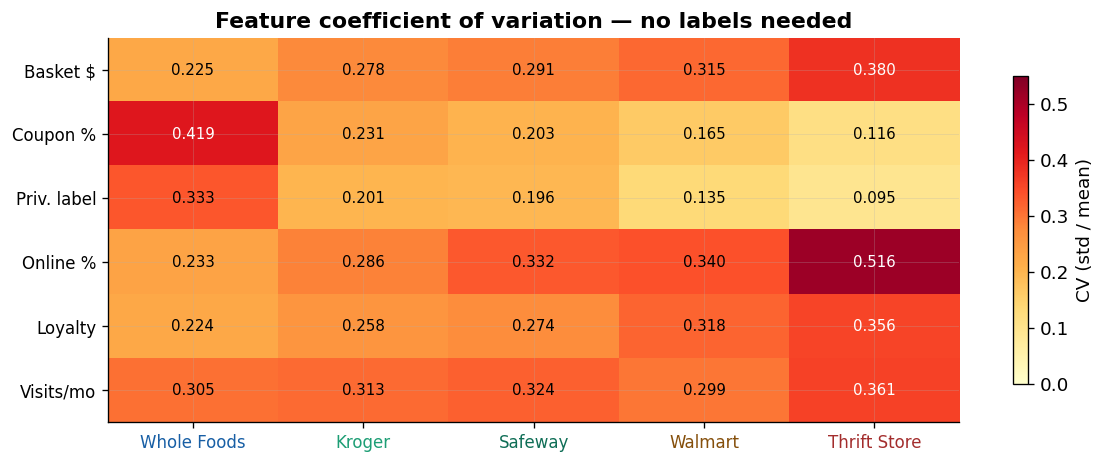


Highest CV per store (most variable feature):
  Whole Foods     → coupon_usage_pct  CV=0.419
  Kroger          → visits_per_month  CV=0.313
  Safeway         → online_orders_pct  CV=0.332
  Walmart         → online_orders_pct  CV=0.340
  Thrift Store    → online_orders_pct  CV=0.516


In [4]:
cv_mat = np.array([[feat_stats[s][f]["cv"] for f in SIX] for s in STORES])

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(cv_mat.T, cmap="YlOrRd", aspect="auto", vmin=0, vmax=0.55)

ax.set_xticks(range(len(STORES))); ax.set_xticklabels(LABELS, fontsize=10)
ax.set_yticks(range(len(SIX)));    ax.set_yticklabels(SIX_LABS, fontsize=10)
for j, col in enumerate(COLORS): ax.get_xticklabels()[j].set_color(col)
for r in range(len(SIX)):
    for c in range(len(STORES)):
        v = cv_mat[c, r]
        ax.text(c, r, f"{v:.3f}", ha="center", va="center",
                fontsize=9, color="white" if v > 0.35 else "black")
plt.colorbar(im, ax=ax, label="CV (std / mean)", shrink=0.8)
ax.set_title("Feature coefficient of variation — no labels needed", fontweight="bold")
plt.tight_layout(); plt.show()

print("\nHighest CV per store (most variable feature):")
for s, lbl in zip(STORES, LABELS):
    best_f = max(SIX, key=lambda f: feat_stats[s][f]["cv"])
    print(f"  {lbl:<15} → {best_f}  CV={feat_stats[s][best_f]['cv']:.3f}")

## 5. Multivariate variability — total feature variance and effective dimensionality

**Total variance** = trace of the covariance matrix = sum of variances across all features.
Higher total variance = customers are more spread out in feature space.

**Effective dimensionality** = 1 / Σ(eigenvalue_i / total)² (participation ratio).
Measures how many dimensions actually matter. Close to 1 = one dominant direction.
Close to n_features = variance evenly spread across all features.

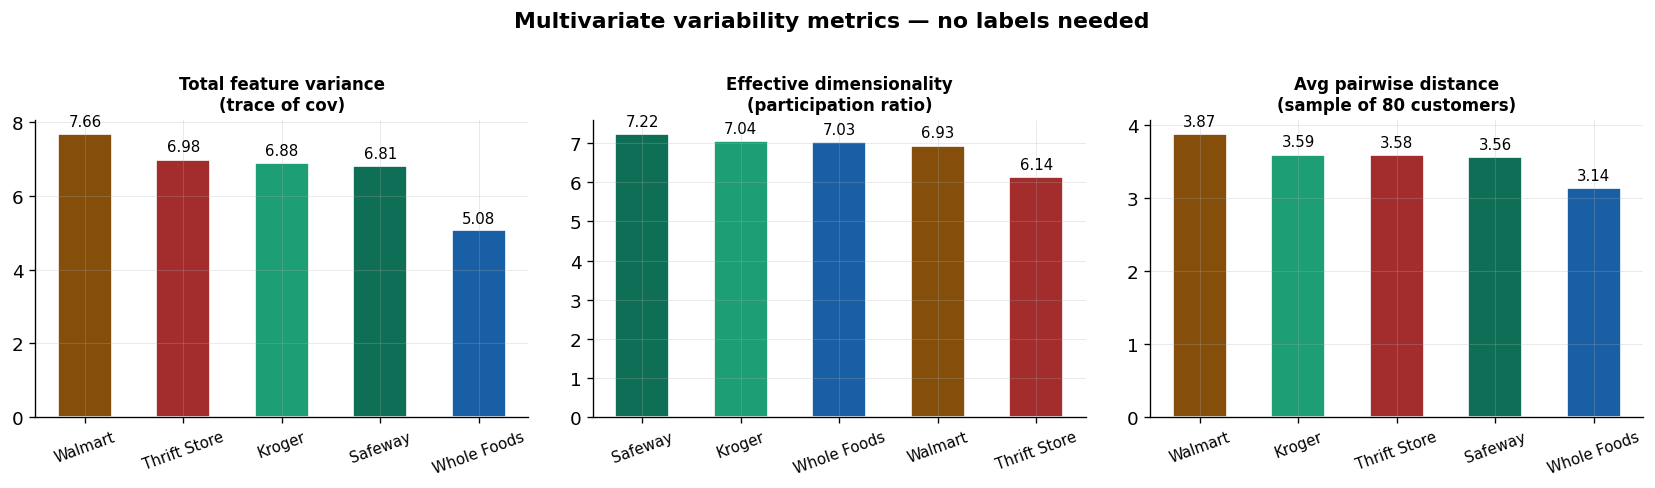


Full results:
  Store              Total var    Eff. dims     Avg dist
  ----------------------------------------------------
  Whole Foods            5.075         7.03        3.138
  Kroger                 6.878         7.04        3.591
  Safeway                6.808         7.22        3.559
  Walmart                7.659         6.93        3.867
  Thrift Store           6.976         6.14        3.583


In [5]:
multivar = {}
for s, lbl in zip(STORES, LABELS):
    Xs = scaler.transform(df[df["store"]==s][FEAT_COLS].values.astype(float))
    cov = np.cov(Xs.T)
    evals = np.linalg.eigvalsh(cov)
    evals = np.maximum(evals, 0)               # numerical safety
    total_var  = float(np.trace(cov))
    eff_dim    = 1.0 / (np.sum((evals/evals.sum())**2) + 1e-12)

    # Average pairwise distance (sample 80 customers for speed)
    idx   = np.random.choice(len(Xs), min(80, len(Xs)), replace=False)
    dmat  = np.linalg.norm(Xs[idx][:,None,:] - Xs[idx][None,:,:], axis=-1)
    avg_d = float(dmat[np.triu_indices_from(dmat, k=1)].mean())

    multivar[s] = {"label": lbl, "total_var": total_var,
                   "eff_dim": eff_dim, "avg_pairwise": avg_d}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [("total_var","Total feature variance\n(trace of cov)"),
           ("eff_dim",  "Effective dimensionality\n(participation ratio)"),
           ("avg_pairwise","Avg pairwise distance\n(sample of 80 customers)")]

for ax, (key, title) in zip(axes, metrics):
    vals   = [multivar[s][key] for s in STORES]
    sorted_pairs = sorted(zip(vals, LABELS, COLORS), reverse=True)
    bars = ax.bar([p[1] for p in sorted_pairs],
                  [p[0] for p in sorted_pairs],
                  color=[p[2] for p in sorted_pairs],
                  edgecolor="white", width=0.55)
    for bar, (v, _, _) in zip(bars, sorted_pairs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+bar.get_height()*0.02,
                f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.tick_params(axis="x", labelsize=9, rotation=20)

plt.suptitle("Multivariate variability metrics — no labels needed", fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

print("\nFull results:")
print(f"  {'Store':<15} {'Total var':>12} {'Eff. dims':>12} {'Avg dist':>12}")
print("  "+"-"*52)
for s, lbl in zip(STORES, LABELS):
    m = multivar[s]
    print(f"  {lbl:<15} {m['total_var']:>12.3f} {m['eff_dim']:>12.2f} {m['avg_pairwise']:>12.3f}")

## 6. PCA scatter — all customers in 2-D feature space (no labels)

Without income labels, we colour by store identity only.
The separation of clusters reveals how different stores are in behavioral space.

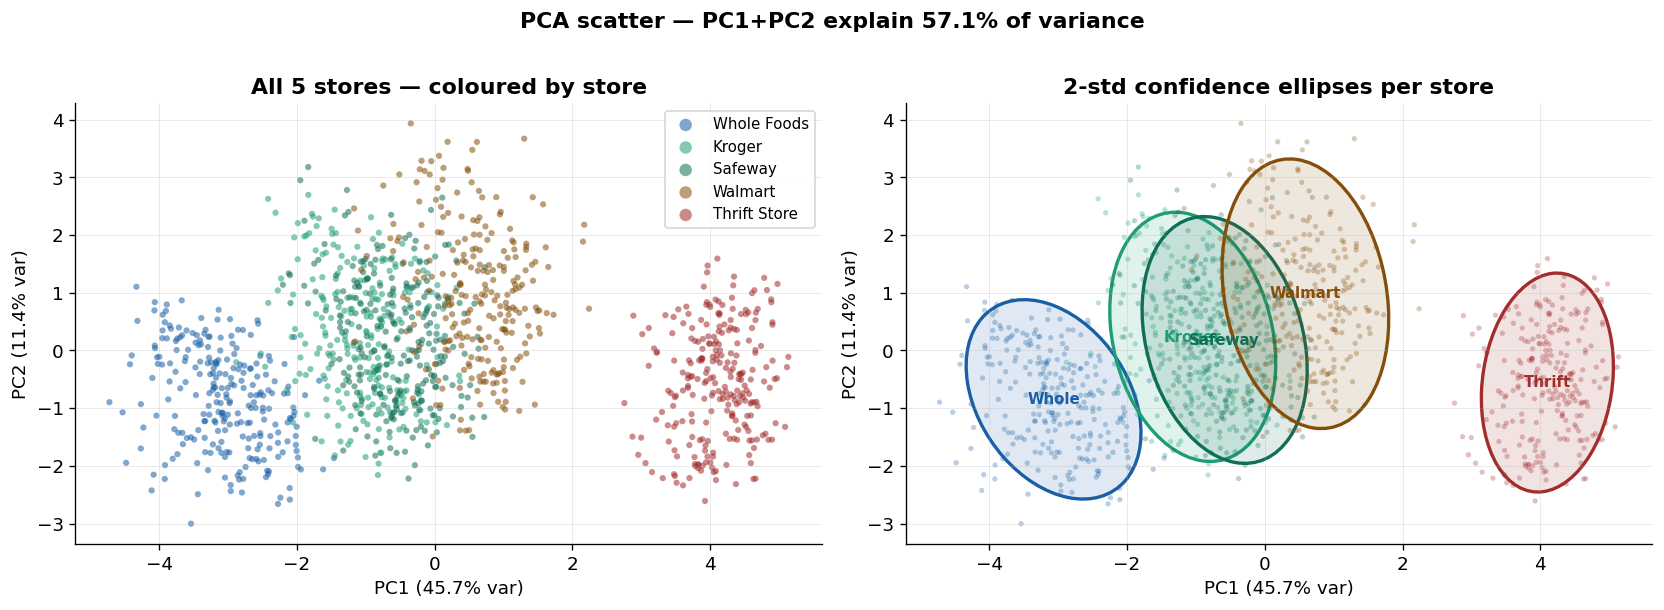

In [6]:
Xg  = scaler.transform(df[FEAT_COLS].values.astype(float))
pca = PCA(n_components=2, random_state=42)
Xp  = pca.fit_transform(Xg)
ev  = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: all stores together ────────────────────────────────────────────────
ax = axes[0]
for s, lbl, col in zip(STORES, LABELS, COLORS):
    mask = df["store"].values == s
    ax.scatter(Xp[mask,0], Xp[mask,1], c=col, s=14, alpha=0.55,
               label=lbl, edgecolors="none")
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)"); ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
ax.set_title("All 5 stores — coloured by store", fontweight="bold")
ax.legend(fontsize=9, markerscale=2)

# ── Right: PCA confidence ellipses per store ─────────────────────────────────
ax = axes[1]
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    cov = np.cov(x, y)
    pearson = cov[0,1]/np.sqrt(cov[0,0]*cov[1,1])
    rx, ry = np.sqrt(1+pearson), np.sqrt(1-pearson)
    ellipse = Ellipse((0,0), width=rx*2, height=ry*2, **kwargs)
    scale_x = np.sqrt(cov[0,0]) * n_std
    scale_y = np.sqrt(cov[1,1]) * n_std
    t = (transforms.Affine2D()
         .rotate_deg(45)
         .scale(scale_x, scale_y)
         .translate(x.mean(), y.mean()))
    ellipse.set_transform(t + ax.transData)
    return ax.add_patch(ellipse)

for s, lbl, col in zip(STORES, LABELS, COLORS):
    mask = df["store"].values == s
    ax.scatter(Xp[mask,0], Xp[mask,1], c=col, s=10, alpha=0.3, edgecolors="none")
    confidence_ellipse(Xp[mask,0], Xp[mask,1], ax, n_std=2,
                       edgecolor=col, facecolor=col+"22", linewidth=2, label=lbl)
    cx, cy = Xp[mask,0].mean(), Xp[mask,1].mean()
    ax.text(cx, cy, lbl.split()[0], ha="center", va="center",
            fontsize=9, fontweight="bold", color=col)

ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)"); ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
ax.set_title("2-std confidence ellipses per store", fontweight="bold")

plt.suptitle(f"PCA scatter — PC1+PC2 explain {sum(ev)*100:.1f}% of variance",
             fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

## 7. External shift — KS and Wasserstein between stores (no labels)

Without income labels, we can still ask:
*How different is store A from store B in behavioral feature space?*

This requires picking a **reference store** — any labeled store works.
The shift metrics are fully label-free.

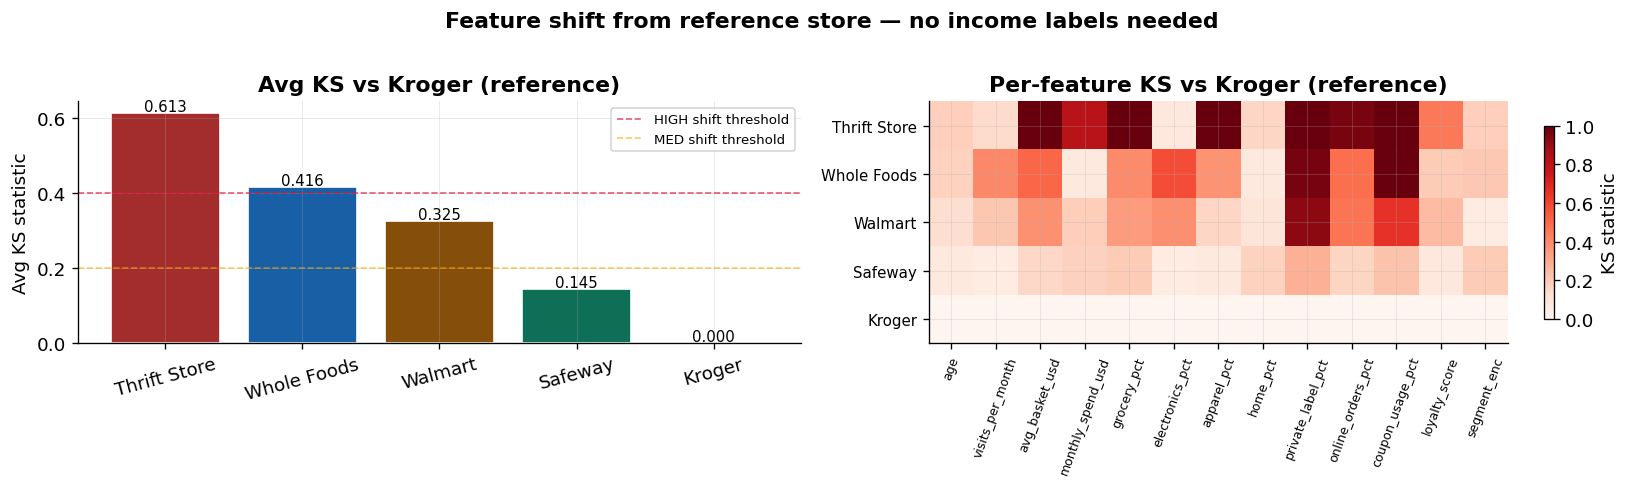

In [7]:
# Use Kroger as the reference (median tier, most central)
ref_store = "kroger"
ref_label = "Kroger (reference)"
ref_df = df[df["store"]==ref_store]

results = []
for s, lbl in zip(STORES, LABELS):
    tgt_df = df[df["store"]==s]
    ks_vals   = [ks_2samp(ref_df[f].values, tgt_df[f].values)[0] for f in FEAT_COLS]
    wass_vals = [wasserstein_distance(
                     scaler.transform(ref_df[FEAT_COLS].values.astype(float))[:,i],
                     scaler.transform(tgt_df[FEAT_COLS].values.astype(float))[:,i])
                 for i in range(len(FEAT_COLS))]
    results.append({
        "store": s, "label": lbl,
        "avg_ks":   np.mean(ks_vals),
        "max_ks":   np.max(ks_vals),
        "avg_wass": np.mean(wass_vals),
        "per_feature_ks": dict(zip(FEAT_COLS, ks_vals)),
    })

# Sort by avg KS (most shifted last)
results.sort(key=lambda r: r["avg_ks"], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Avg KS bar ───────────────────────────────────────────────────────────────
ax = axes[0]
clrs = [COLORS[STORES.index(r["store"])] for r in results]
bars = ax.bar([r["label"] for r in results],
              [r["avg_ks"] for r in results], color=clrs, edgecolor="white")
ax.axhline(0.4, color="crimson", linestyle="--", linewidth=1, alpha=0.7, label="HIGH shift threshold")
ax.axhline(0.2, color="orange",  linestyle="--", linewidth=1, alpha=0.6, label="MED shift threshold")
for bar, r in zip(bars, results):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{r['avg_ks']:.3f}", ha="center", fontsize=9)
ax.set_ylabel("Avg KS statistic"); ax.set_title(f"Avg KS vs {ref_label}", fontweight="bold")
ax.legend(fontsize=8); ax.tick_params(axis="x", rotation=15)

# ── Per-feature KS heatmap ───────────────────────────────────────────────────
ax = axes[1]
ks_mat = np.array([[r["per_feature_ks"][f] for f in FEAT_COLS] for r in results])
im = ax.imshow(ks_mat, cmap="Reds", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(FEAT_COLS))); ax.set_xticklabels(FEAT_COLS, rotation=70, fontsize=7.5)
ax.set_yticks(range(len(results)));   ax.set_yticklabels([r["label"] for r in results], fontsize=9)
plt.colorbar(im, ax=ax, label="KS statistic", shrink=0.8)
ax.set_title(f"Per-feature KS vs {ref_label}", fontweight="bold")

plt.suptitle("Feature shift from reference store — no income labels needed", fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

## 8. Classifier discrepancy — the most powerful shift detector (no labels)

Train a binary classifier to distinguish store A from store B using features only.
If it succeeds → large behavioral shift. No income labels involved at any point.

**Normalized discrepancy = 2 × (accuracy − 0.5)**
- 0.0 = stores are behaviorally indistinguishable
- 1.0 = perfectly separated

  Whole Foods      accuracy=0.998  discrepancy=0.996
  Kroger           accuracy=0.500  discrepancy=0.000
  Safeway          accuracy=0.788  discrepancy=0.576
  Walmart          accuracy=0.986  discrepancy=0.972
  Thrift Store     accuracy=1.000  discrepancy=1.000


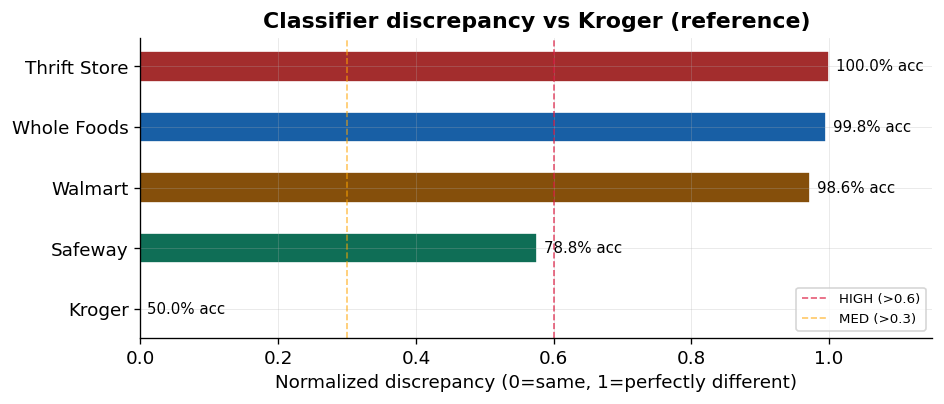

In [8]:
ref_Xs = scaler.transform(
    df[df["store"]==ref_store][FEAT_COLS].values.astype(float))

disc_results = []
for s, lbl in zip(STORES, LABELS):
    tgt_Xs = scaler.transform(
        df[df["store"]==s][FEAT_COLS].values.astype(float))
    X_clf = np.vstack([ref_Xs, tgt_Xs])
    y_clf = np.array([0]*len(ref_Xs) + [1]*len(tgt_Xs))
    clf   = GradientBoostingClassifier(n_estimators=80, max_depth=3, random_state=42)
    acc   = cross_val_score(clf, X_clf, y_clf, cv=5, scoring="accuracy").mean()
    disc  = 2 * (acc - 0.5)
    disc_results.append({"label": lbl, "store": s, "acc": acc, "disc": disc})
    print(f"  {lbl:<15}  accuracy={acc:.3f}  discrepancy={disc:.3f}")

disc_results.sort(key=lambda r: r["disc"], reverse=True)

fig, ax = plt.subplots(figsize=(8, 3.5))
clrs = [COLORS[STORES.index(r["store"])] for r in disc_results]
bars = ax.barh([r["label"] for r in disc_results],
               [r["disc"] for r in disc_results],
               color=clrs, edgecolor="white", height=0.5)
ax.axvline(0.6, color="crimson", linestyle="--", linewidth=1, alpha=0.7, label="HIGH (>0.6)")
ax.axvline(0.3, color="orange",  linestyle="--", linewidth=1, alpha=0.6, label="MED (>0.3)")
for bar, r in zip(bars, disc_results):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f"{r['acc']:.1%} acc", va="center", fontsize=9)
ax.set_xlabel("Normalized discrepancy (0=same, 1=perfectly different)")
ax.set_title(f"Classifier discrepancy vs {ref_label}", fontweight="bold")
ax.set_xlim(0, 1.15); ax.legend(fontsize=8); ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 9. PCA centroid distance matrix — all store pairs (no labels)

Euclidean distance between store centroids in PCA space.
Symmetric matrix: each cell = how far apart two stores are in behavioral feature space.

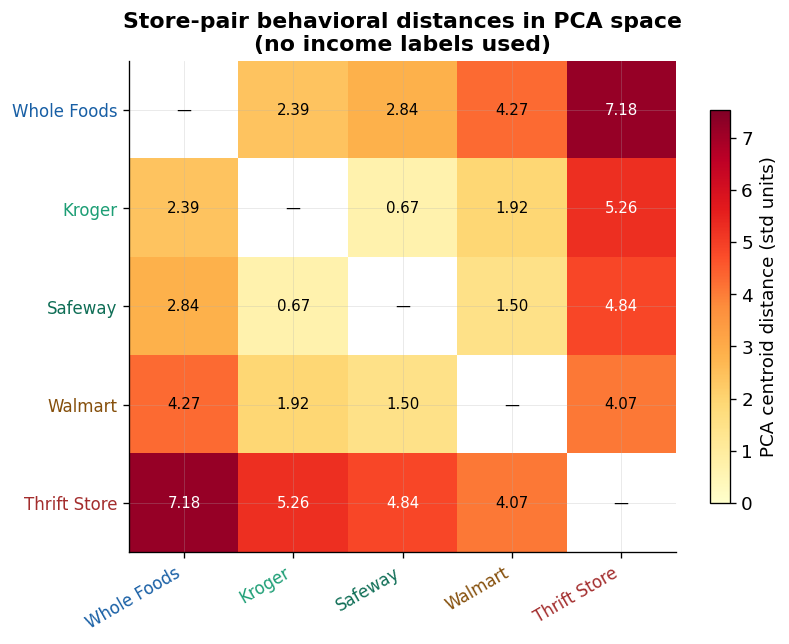


Most similar pair:  Kroger ↔ Safeway  dist=0.671
Most different pair: Whole Foods ↔ Thrift Store  dist=7.176


In [9]:
Xg  = scaler.transform(df[FEAT_COLS].values.astype(float))
pca6 = PCA(n_components=6, random_state=42)
Xp6  = pca6.fit_transform(Xg)

centroids = np.array([Xp6[df["store"].values==s].mean(axis=0) for s in STORES])
dist_mat  = np.array([[np.linalg.norm(centroids[i]-centroids[j])
                        for j in range(len(STORES))]
                       for i in range(len(STORES))])

fig, ax = plt.subplots(figsize=(7, 5.5))
mask_diag = np.eye(len(STORES), dtype=bool)
im = ax.imshow(np.where(mask_diag, np.nan, dist_mat),
               cmap="YlOrRd", aspect="auto", vmin=0, vmax=dist_mat.max()*1.05)
ax.set_xticks(range(len(STORES))); ax.set_xticklabels(LABELS, rotation=30, ha="right", fontsize=10)
ax.set_yticks(range(len(STORES))); ax.set_yticklabels(LABELS, fontsize=10)
for j, col in enumerate(COLORS):
    ax.get_xticklabels()[j].set_color(col)
    ax.get_yticklabels()[j].set_color(col)
for i in range(len(STORES)):
    for j in range(len(STORES)):
        txt = "—" if i==j else f"{dist_mat[i,j]:.2f}"
        ax.text(j, i, txt, ha="center", va="center", fontsize=9,
                color="white" if (not mask_diag[i,j] and dist_mat[i,j]>dist_mat.max()*0.6) else "black")
plt.colorbar(im, ax=ax, label="PCA centroid distance (std units)", shrink=0.8)
ax.set_title("Store-pair behavioral distances in PCA space\n(no income labels used)",
             fontweight="bold")
plt.tight_layout(); plt.show()

print("\nMost similar pair:  ", end="")
np.fill_diagonal(dist_mat, np.inf)
idx = np.unravel_index(dist_mat.argmin(), dist_mat.shape)
print(f"{LABELS[idx[0]]} ↔ {LABELS[idx[1]]}  dist={dist_mat[idx]:.3f}")
np.fill_diagonal(dist_mat, 0)
print("Most different pair:", end=" ")
idx2 = np.unravel_index(dist_mat.argmax(), dist_mat.shape)
print(f"{LABELS[idx2[0]]} ↔ {LABELS[idx2[1]]}  dist={dist_mat[idx2]:.3f}")

## 10. Outlier detection — no labels needed

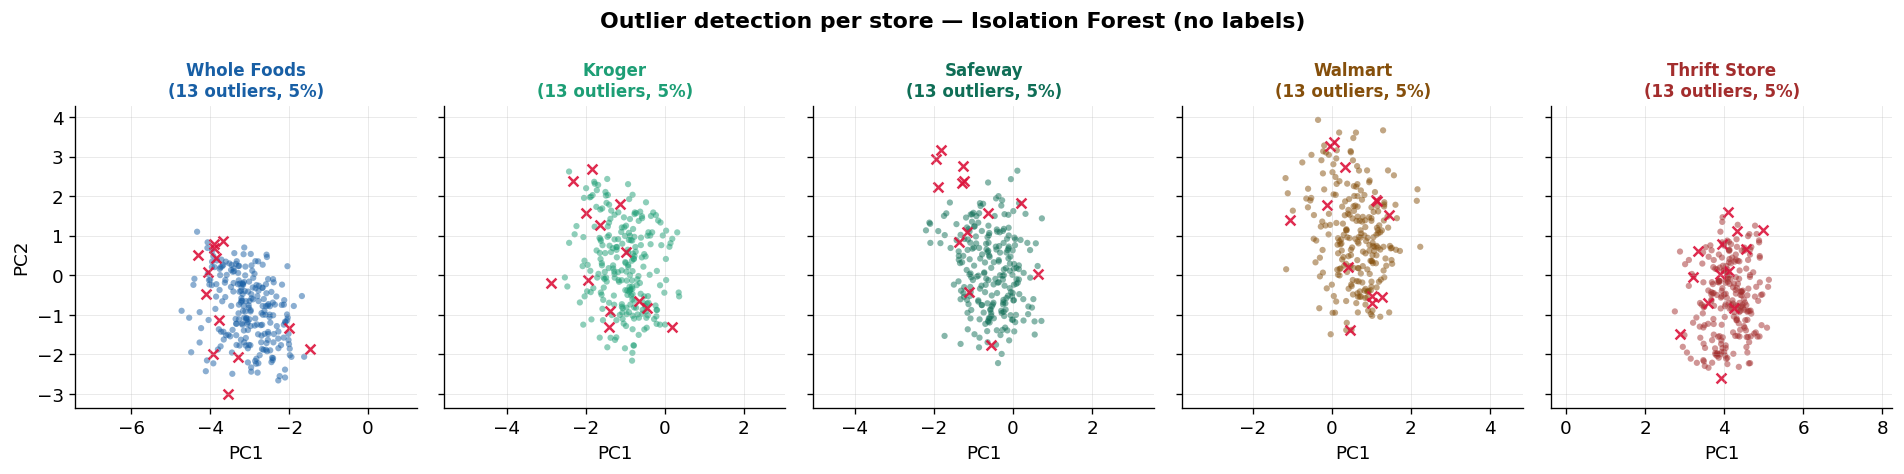

In [10]:
from sklearn.ensemble import IsolationForest

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
fig.suptitle("Outlier detection per store — Isolation Forest (no labels)", fontweight="bold")

for ax, s, lbl, col in zip(axes, STORES, LABELS, COLORS):
    Xs = scaler.transform(df[df["store"]==s][FEAT_COLS].values.astype(float))
    Xp2 = pca6.transform(Xs)[:, :2]

    iso = IsolationForest(contamination=0.05, random_state=42)
    preds = iso.fit_predict(Xs)           # -1 = outlier, +1 = inlier
    n_out = (preds==-1).sum()

    ax.scatter(Xp2[preds==1, 0], Xp2[preds==1, 1],
               c=col, s=14, alpha=0.5, edgecolors="none", label="Normal")
    ax.scatter(Xp2[preds==-1, 0], Xp2[preds==-1, 1],
               c="crimson", s=35, alpha=0.9, marker="x", linewidths=1.5, label="Outlier")
    ax.set_title(f"{lbl}\n({n_out} outliers, {n_out/len(Xs)*100:.0f}%)",
                 fontsize=10, fontweight="bold", color=col)
    ax.set_xlabel("PC1"); ax.set_aspect("equal", "datalim")
axes[0].set_ylabel("PC2")
plt.tight_layout(); plt.show()

## 11. Summary — what you get without labels

All metrics below are computed from behavioral features only, **no income labels used**.

In [11]:
rows = []
for s, lbl in zip(STORES, LABELS):
    sub_df = df[df["store"]==s]
    Xs = scaler.transform(sub_df[FEAT_COLS].values.astype(float))
    cov = np.cov(Xs.T)
    evals = np.maximum(np.linalg.eigvalsh(cov), 0)
    eff_dim = 1.0 / (np.sum((evals/evals.sum())**2) + 1e-12)

    # KS vs Kroger reference
    ref_sub = df[df["store"]==ref_store]
    avg_ks = np.mean([ks_2samp(ref_sub[f].values, sub_df[f].values)[0]
                      for f in FEAT_COLS])

    # PCA distance to Kroger centroid
    ref_cen = Xp6[df["store"].values==ref_store].mean(axis=0)
    my_cen  = Xp6[df["store"].values==s].mean(axis=0)
    pca_d   = np.linalg.norm(my_cen - ref_cen)

    # Iso Forest outlier rate
    iso = IsolationForest(contamination=0.05, random_state=42)
    out_rate = (iso.fit_predict(Xs)==-1).mean() * 100

    # Most variable feature
    cvs_all = [sub_df[f].std()/(sub_df[f].mean()+1e-9) for f in FEAT_COLS]
    top_feat = FEAT_COLS[int(np.argmax(cvs_all))]

    # Classifier disc vs Kroger
    d_row = next(r for r in disc_results if r["store"]==s)

    rows.append({
        "Store":            lbl,
        "Total feat. var":  f"{np.trace(cov):.3f}",
        "Eff. dims":        f"{eff_dim:.2f}",
        "Avg KS vs Kroger": f"{avg_ks:.3f}",
        "PCA dist (Kroger)":f"{pca_d:.2f}",
        "Classifier disc.": f"{d_row['disc']:.3f}",
        "Outlier rate":     f"{out_rate:.1f}%",
        "Most variable feat": top_feat.replace("_pct","").replace("_usd","").replace("_"," "),
    })

display(pd.DataFrame(rows).set_index("Store"))

print("\nAll of the above metrics required ZERO income labels.")
print("They quantify HOW SPREAD OUT and HOW DIFFERENT each store's customers are,")
print("purely from behavioral features.")

,Total feat. var,Eff. dims,Avg KS vs Kroger,PCA dist (Kroger),Classifier disc.,Outlier rate,Most variable feat
Store,,,,,,,
Whole Foods,5.075,7.03,0.416,2.39,0.996,5.2%,segment enc
Kroger,6.878,7.04,0.000,0.00,0.000,5.2%,segment enc
Safeway,6.808,7.22,0.145,0.67,0.576,5.2%,segment enc
Walmart,7.659,6.93,0.325,1.92,0.972,5.2%,segment enc
Thrift Store,6.976,6.14,0.613,5.26,1.000,5.2%,segment enc



All of the above metrics required ZERO income labels.
They quantify HOW SPREAD OUT and HOW DIFFERENT each store's customers are,
purely from behavioral features.
